## Carregando os dados

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

# importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix

#importando o arquivo
df = pd.read_csv('Base_Treinamento.csv', sep=',')
df.head()


,id,data_criacao,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,BCS-00163074,2026-02-22 10:34:58.338000+00:00,Outros Problemas com Postes,51,Sim,Não,Não,URGENTE
1,BCS-00172400,2026-03-07 09:40:54.637000+00:00,Outros Problemas com Postes,38,Não,Sim,Não,ALTA
2,BCS-00166754,2026-02-25 09:02:46.448000+00:00,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,BCS-00171257,2026-03-04 23:15:53.768443+00:00,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,BCS-00065327,2025-08-01 06:35:06.539000+00:00,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE


## Pré-processamento: eliminação de atributos irrelevantes

In [2]:
# remove as colunas id e data_criacao
df = df.drop(columns=['id','data_criacao'])

# imprime o dataframe
display(df)

,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,Outros Problemas com Postes,51,Sim,Não,Não,URGENTE
1,Outros Problemas com Postes,38,Não,Sim,Não,ALTA
2,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
...,...,...,...,...,...,...
8634,Luz Queimada,2,Não,Não,Não,BAIXA
8635,Lixo e Detritos,1,Não,Sim,Não,MEDIA
8636,Problema com Animal Doméstico,91,Sim,Não,Sim,URGENTE
8637,Problema com Animal Doméstico,7,Sim,Não,Sim,ALTA


Retirados os atributos id e data_criacao:

id -> Desnecessário para análise;
data_criacao -> Refeleta data de criação do chamdo, não tem relação com o atributo dias_problemas, e não deve serc onsiderado na análise, pois o chamado deve ser classificado no mesmo dia, não interferindo esse campo na classe urgencia;

Mantidos os campos:

dias_problemas -> O usuário informará quantos dias que fazem que o problema relatado no chamado existe, não necessáriamente é no mesmo dia da abertura do chamdo, pode ser antes; (Atributo contínuo)
risco_vida_humana -> Atributo descritivo, podendo ser Sim ou Não
risco_vida_animal -> Atributo descritivo, podendo ser Sim ou Não
bloqueio_via -> Atributo descritivo, podendo ser Sim ou Não

urgencia -> classe descritiva (URGENTE, ALTA, MEDIA, BAIXA)

## Pré-processamento: tratamento de atributos com valores ausentes

In [3]:
# índices das linhas que contém valores NaN
idxRowNan = pd.isnull(df).any(axis=1).to_numpy().nonzero()

# imprime apenas as linhas com valoes ausentes
display(df.iloc[idxRowNan])

,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia


Nenhum atributo ausente encontrado

## Pré-processamento: tratamento de dados inconsistentes ou redundantes

In [4]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana', 'risco_vida_animal','bloqueio_via'],keep=False)]

# se houver valores redundantes ou inconsistentes, imprima
if len(df_duplicates)>0:
    print('\nAmostras redundantes ou inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores duplicados')


Amostras redundantes ou inconsistentes:


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
2,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
5,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
6,Problema com Animal Selvagem,256,Sim,Sim,Não,URGENTE
...,...,...,...,...,...,...
8629,Luz Queimada Poste,4,Sim,Não,Sim,URGENTE
8632,Manutenção da Área Verde,2,Sim,Não,Não,ALTA
8633,Manutenção da Área Verde,2,Não,Sim,Não,BAIXA
8635,Lixo e Detritos,1,Não,Sim,Não,MEDIA


In [5]:
def delDuplicatas(df):
   '''
   Para cada grupo de amostras duplicadas, mantém uma e apaga as demais
   '''

   # remove as amostras duplicadas, mantendo apenas a primeira ocorrencia
   df = df.drop_duplicates(keep = 'first')

   return df

df = delDuplicatas(df)

display(df)


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,Outros Problemas com Postes,51,Sim,Não,Não,URGENTE
1,Outros Problemas com Postes,38,Não,Sim,Não,ALTA
2,Luz Queimada Poste,48,Sim,Não,Sim,URGENTE
3,Luz Queimada Poste,41,Sim,Não,Sim,URGENTE
4,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
...,...,...,...,...,...,...
8630,Lixo e Detritos,4,Não,Sim,Não,ALTA
8631,Manutenção da Área Verde,3,Sim,Não,Não,ALTA
8634,Luz Queimada,2,Não,Não,Não,BAIXA
8637,Problema com Animal Doméstico,7,Sim,Não,Sim,ALTA


Removidas linhas redundantes, no total de 3228 linhas redundantes removidas

In [6]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

# para detectar inconsistências, a rotina abaixo obtém as amostras onde os valores
# dos atributos continuam duplicados. Neste caso, os atributos serão iguais, mas as classes serão distintas
df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'],keep=False)]

# se tiver valores inconsistentes, imprime
if len(df_duplicates)>0:
   print('\nAmostras inconsistentes:')
   display(df_duplicates)
else:
   print('Não existem mostras inconsistentes')



Amostras inconsistentes:


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
42,Problema com Animal Selvagem,254,Não,Sim,Não,URGENTE
44,Problema com Animal Selvagem,254,Não,Sim,Não,ALTA
68,Problema com Animal Selvagem,252,Não,Não,Sim,ALTA
72,Problema com Animal Doméstico,252,Não,Não,Sim,URGENTE
74,Problema com Animal Doméstico,252,Não,Não,Sim,ALTA
...,...,...,...,...,...,...
8594,Árvore ou Galhos Caídos,24,Não,Sim,Não,ALTA
8604,Outros Problemas com Postes,15,Sim,Sim,Não,ALTA
8608,Problema com Animal Doméstico,2,Sim,Não,Não,ALTA
8611,Problema com Animal Doméstico,2,Sim,Não,Sim,ALTA


In [7]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

def delInconsistencias(df):
   '''
   Remove todas as amostras inconsistentes da base de dados
   '''

   df = df.drop_duplicates(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'], keep = False)
   return df

df = delInconsistencias(df)

# obtém apenas as amostras onde os valores dos atributos estão duplicados
df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'],keep=False)]

# se tiver valores redundantes ou inconsistentes, imprime
if len(df_duplicates)>0:
   display(df_duplicates)
else:
   print('Não existem amostras redundantes ou inconsistentes')

Não existem amostras redundantes ou inconsistentes


In [8]:
# apresenta as principais estatísticas da base de dados
df_detalhes = df.describe()

display(df_detalhes)


,dias_problema
count,4926.000000
mean,102.401340
std,70.082483
min,1.000000
25%,37.000000
50%,96.000000
75%,156.000000
max,256.000000


## Pré-processamento: normalização dos atributos

In [9]:
def normalizar(X):
   """
   Normaliza os atributos em X

   Esta função retorna uma versao normalizada de X onde o valor da
   média de cada atributo é igual a 0 e desvio padrao é igual a 1. Trata-se de
   um importante passo de pré-processamento quando trabalha-se com
   métodos de aprendizado de máquina.
   """

   m, n = X.shape # m = qtde de objetos e n = qtde de atributos por objeto

   # Incializa as variaves de saída
   X_norm = np.random.rand(m,n) # inicializa X_norm com valores aleatórios
   mu = 0 # inicializa a média
   sigma = 1 # inicializa o desvio padrão

   mu = np.mean(X, axis=0)
   sigma = np.std(X, axis=0, ddof=1)

   for i in range(m):
       X_norm[i,:] = (X[i,:]-mu) / sigma


   return X_norm, mu, sigma

# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia
# reovendo os atributos descritivos e classe da normalização
# coloca os valores dos atributos na variável X
X = df.iloc[:,1:-4].values

# chama a função para normalizar X
X_norm, mu, sigma = normalizar(X)

df.iloc[:,1:-4] = X_norm

print(f"\nMédia: {mu}")
print(f"Desvio padrão: {sigma}")

# Verifique se os dados estão corretos
print(f"\nTotal de amostras: {len(X)}")

print('\nPrimeira amostra da base antes da normalização: [%2.4f].' % X[0,0])
print('\nPrimeira amostra da base após normalização: [%2.4f].' % X_norm[0,0])




Média: [102.40133983]
Desvio padrão: [70.08248302]

Total de amostras: 4926

Primeira amostra da base antes da normalização: [51.0000].

Primeira amostra da base após normalização: [-0.7334].


Executada a normalização, levando a Média a 0 e o Desvio Padrão a 1.

In [23]:
# apresenta as principais estatísticas da base de dados
df_detalhes = df.describe()

display(df_detalhes.round(8))

,dias_problema
count,5411.000000
mean,0.000000
std,1.000000
min,-1.434756
25%,-0.938559
50%,-0.087934
75%,0.762690
max,2.180398


## Pré-processamento: detecção de *outliers*

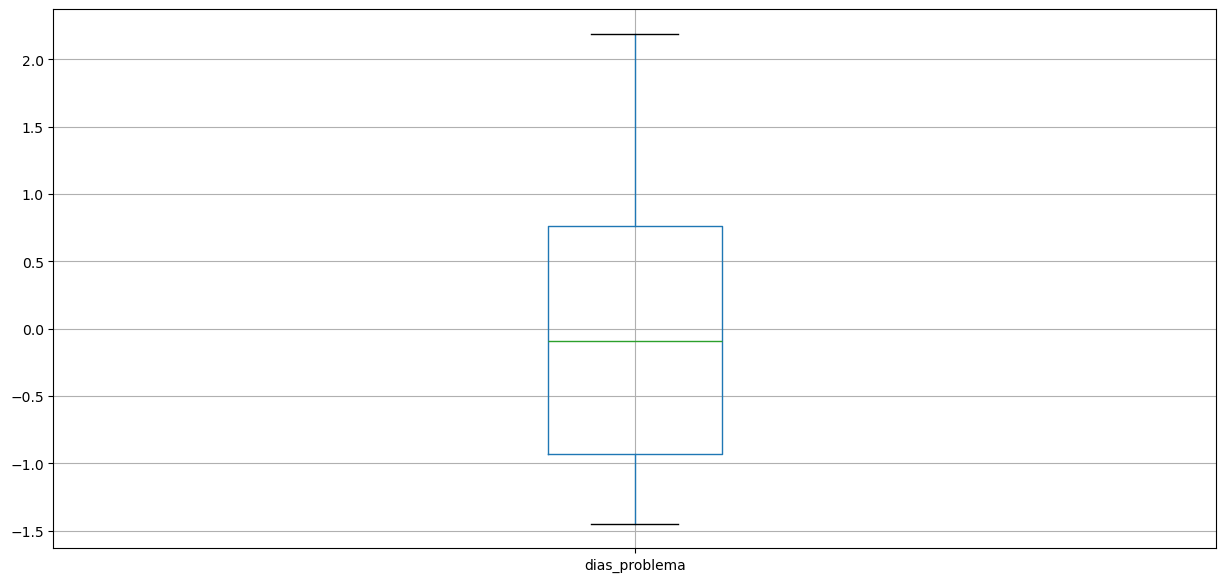

In [10]:
# gera um bloxplot para cada atributo
df.boxplot(figsize=(15,7))
plt.show()


Como Outliers não foram encontrados, não é possível verificar se são erros ou não, não é necessário remove-los

Como não há mais de um atributo numérico, não é possível gerar um gráfico de dispersão. O gráfico de dispersão é utilizado para visualizar a relação entre dois ou mais atributos numéricos.

## Pré-processamento: distribuição das classes

urgencia
URGENTE    3484
ALTA        741
MEDIA       579
BAIXA       122
Name: count, dtype: int64

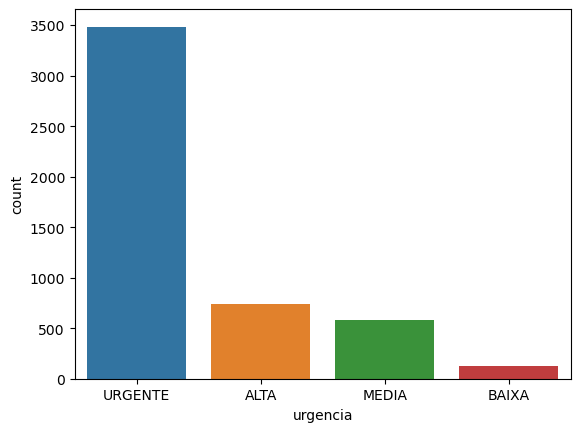

In [11]:
display(df['urgencia'].value_counts())

# cria um gráfico de barras com a frequência de cada urgencia
sns.countplot(x="urgencia", data=df)

# mostra o gráfico
plt.show()

Como somente um atributo é quantitativo, não é possivel criar uma matriz de correlação deles